In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
pa_gs = pd.read_csv('data/pa_data.csv')
pa_gs_cleaned = pa_gs.dropna()

In [4]:
coastal_pa_stations = pa_gs_cleaned[pa_gs_cleaned['dist_atlantic_km']< 150]
lakeside_pa_stations = pa_gs_cleaned[pa_gs_cleaned['dist_greatlakes_km']< 150]
inland_pa_stations = pa_gs_cleaned[pa_gs_cleaned['dist_coast_km']>150]

In [125]:
import seaborn as sns

def scatter_best_fit(data_subset, data_subset_name, xaxis, yaxis, xlabelfull, xlabelabv, ylabelfull, ylabelabv, deg_fit):
    #creates a scatter plot with a best fit line of choice, from a data set or subset, taking in column choices for the x axis
    # and the y axis, preferred labels for each axis and the data set, and the desired degree of the line of best fit.

    #required libraries:  seaborn as sns, matplotlib.pyplot as plt

    #creates title text for degree fit for grammatical accuracy
    if deg_fit == 1:
        fit = 'linear'
    elif deg_fit == 2:
        fit = 'quadratic'
    elif deg_fit == 3:
        fit = 'cubic'
    else:
        fit = f'{deg_fit}th degree'

    #creates scatterplot, best fit line, labels, title, and graphs
    sns.scatterplot(x=data_subset[xaxis], y=data_subset[yaxis])
    sns.regplot(x=data_subset[xaxis], y=data_subset[yaxis], ci=None, order=deg_fit, line_kws={"color":"red"})
    plt.xlabel(xlabelabv)
    plt.ylabel(ylabelabv, fontsize =10)
    plt.title(f'{data_subset_name} {xlabelfull} vs. {ylabelfull} with {fit} best fit line')
    
    return plt.show()

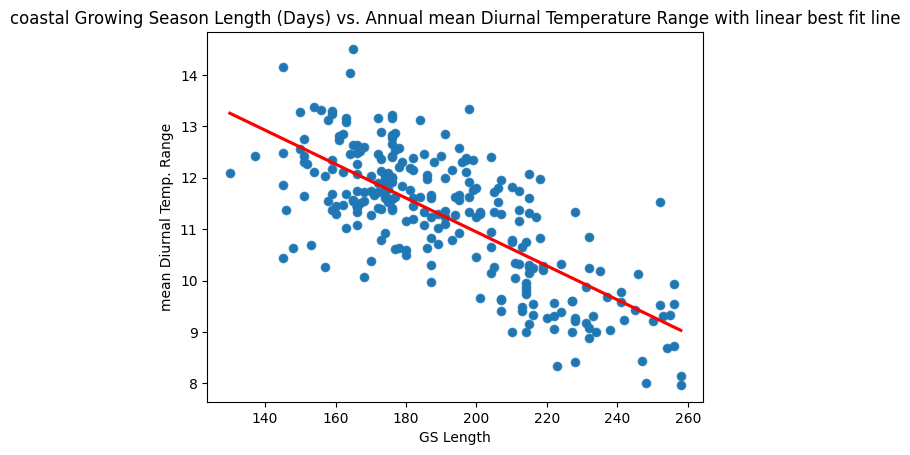

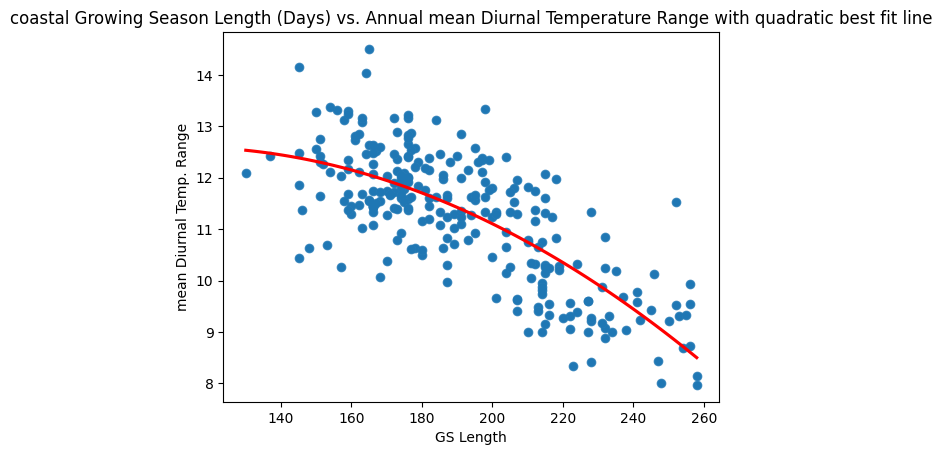

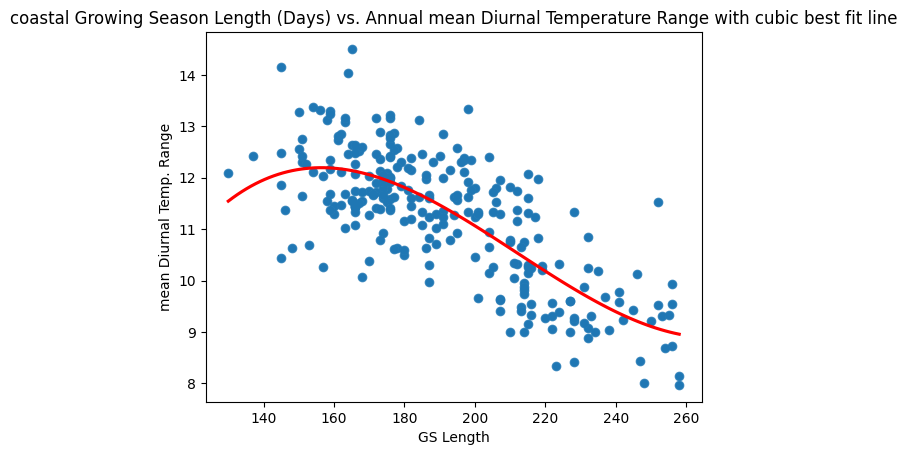

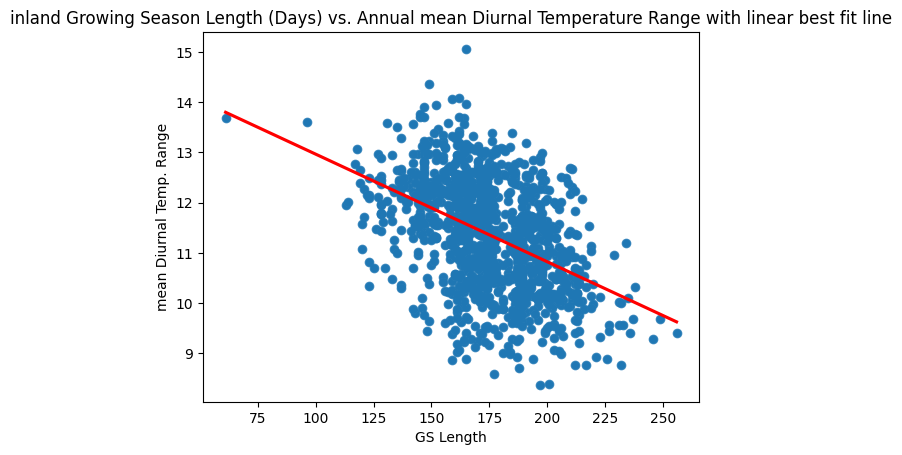

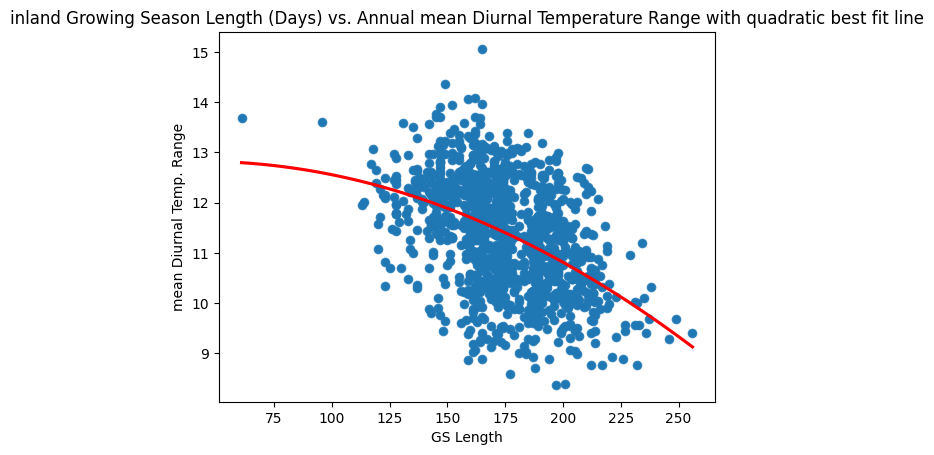

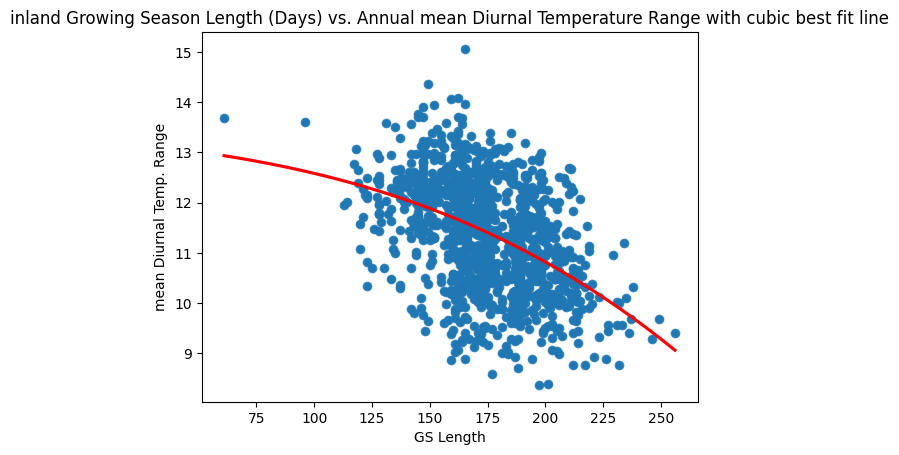

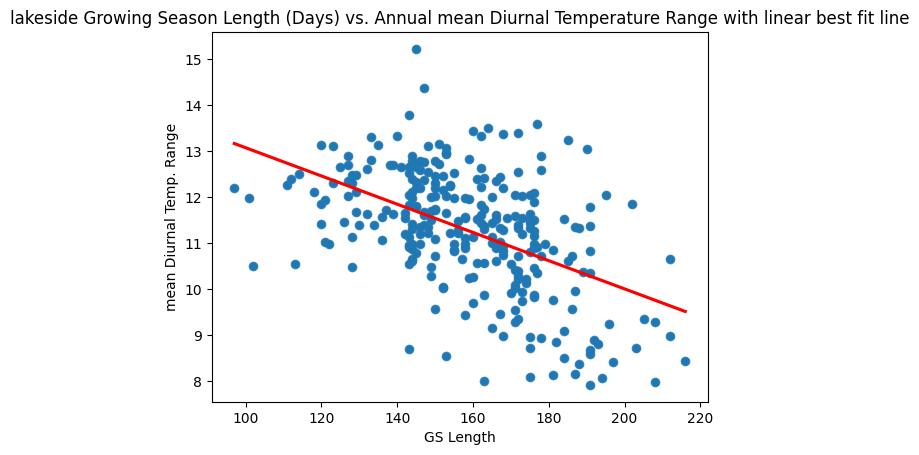

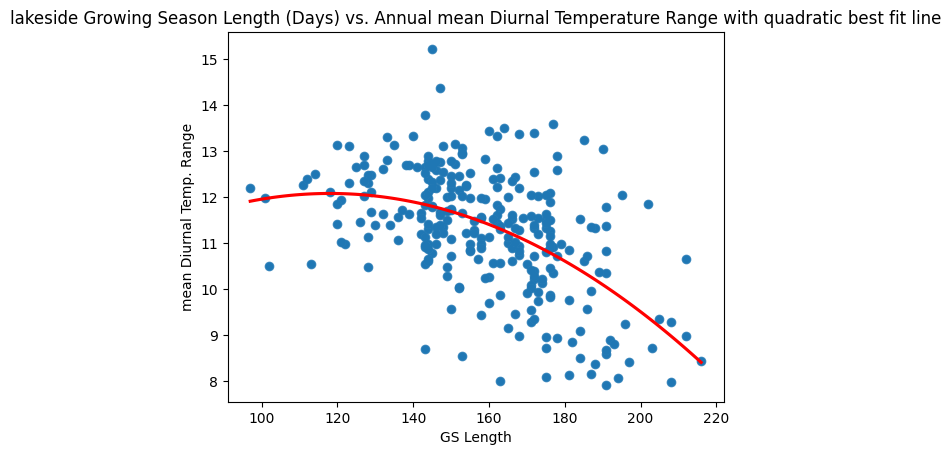

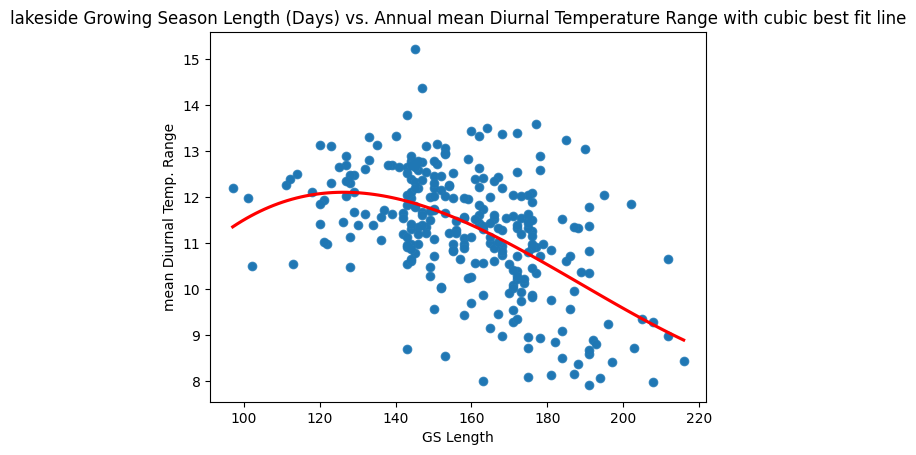

In [126]:
scatter_best_fit(coastal_pa_stations, 'coastal', 'growing_season_length', 'dtr_annual', 'Growing Season Length (Days)', 'GS Length', 
                 'Annual mean Diurnal Temperature Range', 'mean Diurnal Temp. Range', 1)
scatter_best_fit(coastal_pa_stations,'coastal', 'growing_season_length', 'dtr_annual', 'Growing Season Length (Days)', 'GS Length', 
                 'Annual mean Diurnal Temperature Range', 'mean Diurnal Temp. Range', 2) 
scatter_best_fit(coastal_pa_stations,'coastal', 'growing_season_length', 'dtr_annual', 'Growing Season Length (Days)', 'GS Length', 
                 'Annual mean Diurnal Temperature Range', 'mean Diurnal Temp. Range', 3)
scatter_best_fit(inland_pa_stations,'inland', 'growing_season_length', 'dtr_annual', 'Growing Season Length (Days)', 'GS Length', 
                 'Annual mean Diurnal Temperature Range', 'mean Diurnal Temp. Range', 1)
scatter_best_fit(inland_pa_stations,'inland', 'growing_season_length', 'dtr_annual', 'Growing Season Length (Days)', 'GS Length', 
                 'Annual mean Diurnal Temperature Range', 'mean Diurnal Temp. Range', 2) 
scatter_best_fit(inland_pa_stations,'inland', 'growing_season_length', 'dtr_annual', 'Growing Season Length (Days)', 'GS Length', 
                 'Annual mean Diurnal Temperature Range', 'mean Diurnal Temp. Range', 3)
scatter_best_fit(lakeside_pa_stations,'lakeside', 'growing_season_length', 'dtr_annual', 'Growing Season Length (Days)', 'GS Length', 
                 'Annual mean Diurnal Temperature Range', 'mean Diurnal Temp. Range', 1)
scatter_best_fit(lakeside_pa_stations,'lakeside', 'growing_season_length', 'dtr_annual', 'Growing Season Length (Days)', 'GS Length', 
                 'Annual mean Diurnal Temperature Range', 'mean Diurnal Temp. Range', 2)
scatter_best_fit(lakeside_pa_stations,'lakeside', 'growing_season_length', 'dtr_annual', 'Growing Season Length (Days)', 'GS Length', 
                 'Annual mean Diurnal Temperature Range', 'mean Diurnal Temp. Range', 3) 

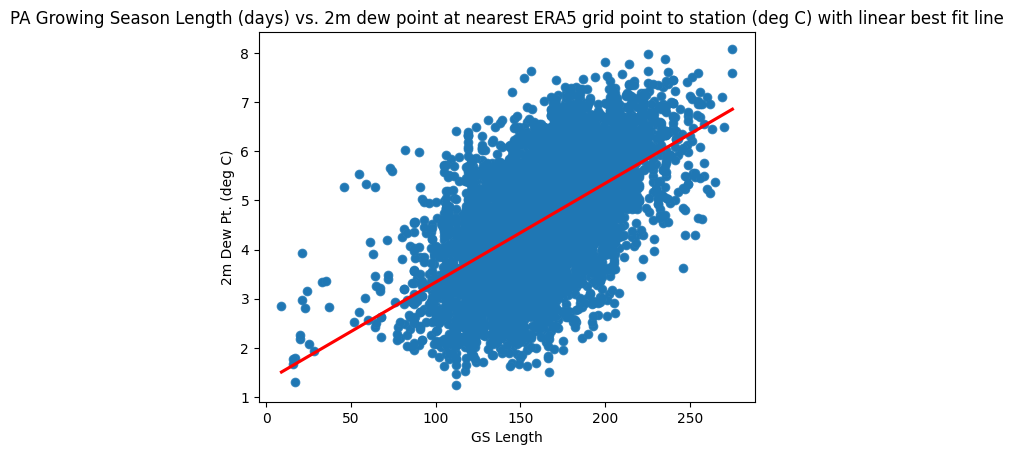

In [148]:
scatter_best_fit(pa_gs, 'PA', 'growing_season_length', 'dewpoint_station', 'Growing Season Length (days)',
'GS Length', '2m dew point at nearest ERA5 grid point to station (deg C)', '2m Dew Pt. (deg C)', 1)

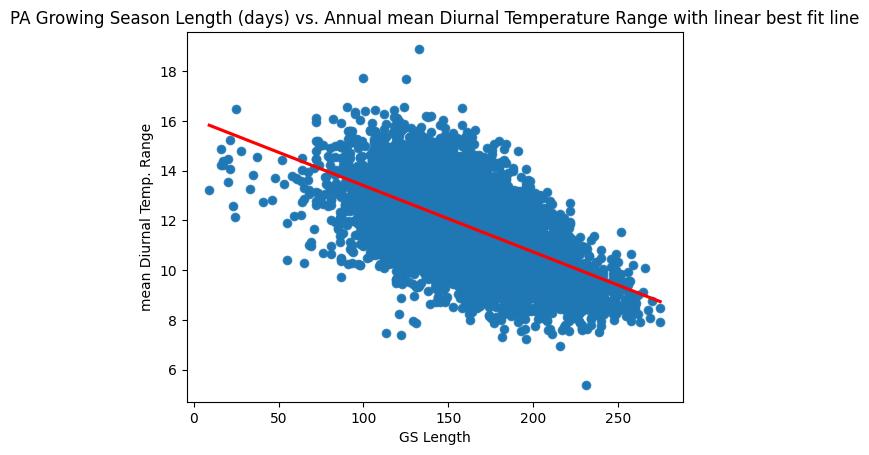

In [153]:
scatter_best_fit(pa_gs, 'PA', 'growing_season_length', 'dtr_annual', 'Growing Season Length (days)',
'GS Length', 'Annual mean Diurnal Temperature Range', 'mean Diurnal Temp. Range', 1)

In [154]:
from scipy.stats import pearsonr

In [158]:
pearsonr(pa_gs_cleaned['growing_season_length'], pa_gs_cleaned['dtr_annual'])

PearsonRResult(statistic=np.float64(-0.47594338665398916), pvalue=np.float64(4.620394189085161e-99))

In [160]:
pearsonr(pa_gs_cleaned['growing_season_length'], pa_gs_cleaned['dewpoint_station'])

PearsonRResult(statistic=np.float64(0.47471141658669136), pvalue=np.float64(1.7251148930591723e-98))